In [32]:
import numpy as np
import matplotlib.pyplot as plt

In [33]:
def Z_term(tau_slow, T_ext):
    return tau_slow * (1 - np.exp(-T_ext / tau_slow))

def C3(z, T_ext, R0, u_ext, r_slow_0):
    return (z-T_ext) / R0 * np.pow(u_ext,3)

def C2(z, T_ext, R0, u_ext, r_slow_0):
    return (3*z - 2 * T_ext) * np.pow(u_ext, 2)

def C1(z, T_ext, R0, u_ext, r_slow_0):
    return (3*z * R0 - T_ext * R0 - z * r_slow_0 / R0) * u_ext

def C0(z, T_ext, R0, u_ext, r_slow_0):
    return z * (np.pow(R0, 2) - r_slow_0)

def r_slow_t(r_slow_0, T_ext, R0, u_ext, w, tau_slow):
    r_j_squared = np.pow((R0 + w * u_ext), 2)
    return r_j_squared - (r_j_squared - r_slow_0) * np.exp(- T_ext / tau_slow)

In [34]:
def delta_w_single(T_ext, R0, u_ext, r_slow_0, tau_slow, alpha, w):
    
    # stim 
    z = Z_term(tau_slow, T_ext)
    c3 = C3(z, T_ext, R0, u_ext, r_slow_0)
    c2 = C2(z, T_ext, R0, u_ext, r_slow_0)
    c1 = C1(z, T_ext, R0, u_ext, r_slow_0)
    c0 = C0(z, T_ext, R0, u_ext, r_slow_0)
    
    ri = R0 + u_ext
    trace_after_stim = r_slow_t(r_slow_0, T_ext, R0, u_ext, w, tau_slow)
    
    stim = alpha * ri * (c3 * np.pow(w, 3) + c2 * np.pow(w, 2) + c1 * w + c0)
    
    return stim, trace_after_stim



def delta_w(T_ext, R0, u_ext, r_slow_0, tau_slow, alpha, w):
    
    # stim 
    z = Z_term(tau_slow, T_ext)
    c3 = C3(z, T_ext, R0, u_ext, r_slow_0)
    c2 = C2(z, T_ext, R0, u_ext, r_slow_0)
    c1 = C1(z, T_ext, R0, u_ext, r_slow_0)
    c0 = C0(z, T_ext, R0, u_ext, r_slow_0)
    
    ri = R0 + u_ext
    trace_after_stim = r_slow_t(r_slow_0, T_ext, R0, u_ext, w, tau_slow)
    
    stim = alpha * ri * (c3 * np.pow(w, 3) + c2 * np.pow(w, 2) + c1 * w + c0)
    
    # after_stim 
    u_ext = 0
    T_ext *= 3
    r_slow_0 = trace_after_stim
    
    
    z = Z_term(tau_slow, T_ext)
    c3 = C3(z, T_ext, R0, u_ext, r_slow_0)
    c2 = C2(z, T_ext, R0, u_ext, r_slow_0)
    c1 = C1(z, T_ext, R0, u_ext, r_slow_0)
    c0 = C0(z, T_ext, R0, u_ext, r_slow_0)
    
    ri = R0
    
    after_stim = alpha * ri * (c3 * np.pow(w, 3) + c2 * np.pow(w, 2) + c1 * w + c0)
    
    return stim + after_stim

def fix_points(T_ext, R0, u_ext, r_slow_0, tau_slow):
    z = Z_term(tau_slow, T_ext)
    c3 = C3(z, T_ext, R0, u_ext, r_slow_0)
    c2 = C2(z, T_ext, R0, u_ext, r_slow_0)
    c1 = C1(z, T_ext, R0, u_ext, r_slow_0)
    c0 = C0(z, T_ext, R0, u_ext, r_slow_0)
    
    fp_1 = (-c2 + np.sqrt(np.pow(c2,2) - 4 * c3 * c1)) / (2*c3)
    fp_2 = (-c2 - np.sqrt(np.pow(c2,2) - 4 * c3 * c1)) / (2*c3)
    
    return fp_1, fp_2
    

In [35]:
R_NULL = 2
ALPHA = 4e-4
R_SLOW_NULL = R_NULL**2

tau_slow = 2.0
ws = np.arange(0, 0.501, 0.1)

T_EXT = 0.1
U_EXT = 17
results_r = delta_w(T_EXT, R_NULL, U_EXT, R_SLOW_NULL, tau_slow, ALPHA, ws)

T_EXT = 4
U_EXT = 5
results_p = delta_w(T_EXT, R_NULL, U_EXT, R_SLOW_NULL, tau_slow, ALPHA, ws)

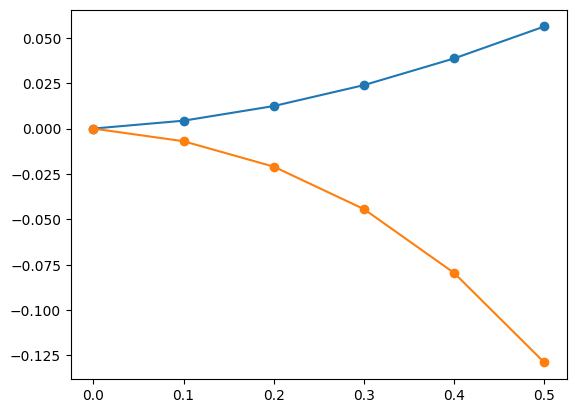

In [36]:
plt.plot(ws, results_r,'-o',)
plt.plot(ws, results_p, '-o')

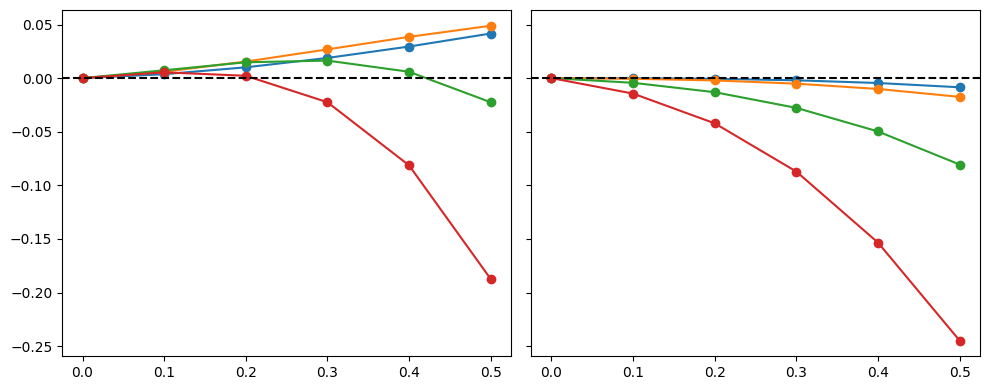

In [37]:
fig, axs = plt.subplot_mosaic([["Short", "Long"]], figsize=(10,4), sharey=True)

ws = np.arange(0,0.501, 0.1)

ts_short = np.array([0.1, 0.2, 0.4, 0.6])
ts_long = np.array([0.8, 1, 2, 4])

params = [ts_short, ts_long]

for (name, ax), param in zip(axs.items(), params):
    
    R_NULL = 2
    ALPHA = 5e-4
    R_SLOW_NULL = R_NULL**2
    u_ext = 5
    tau_slow = 1.0
    
    if name == 'Short':
        for t_ext in param:
            u_ext = 15
            ax.plot(ws, delta_w(t_ext, R_NULL, u_ext, R_SLOW_NULL, tau_slow, ALPHA, ws), marker='o')
        ax.axhline(0, color='black', linestyle='--')
    if name == 'Long':
        for t_ext in param:
            ax.plot(ws, delta_w(t_ext, R_NULL, u_ext, R_SLOW_NULL, tau_slow, ALPHA, ws), marker='o')
        ax.axhline(0, color='black', linestyle='--')
            
fig.tight_layout()

## Gameplay + Reward stimulation

In [ ]:
R_NULL = 2
ALPHA = 2e-4
R_SLOW_NULL = R_NULL**2
tau_slow = 1.
ws = np.arange(0, 0.501, 0.1)

T_EXT = 0.1
U_EXT = 25
results_r = delta_w(T_EXT, R_NULL, U_EXT, R_SLOW_NULL, tau_slow, ALPHA, ws)

T_EXT = 4
U_EXT = 5
results_p = delta_w(T_EXT, R_NULL, U_EXT, R_SLOW_NULL, tau_slow, ALPHA, ws)

t_gp = 0.1

T_EXT = t_gp
U_EXT = 5
dw_gp, trace = delta_w_single(T_EXT, R_NULL, U_EXT, R_SLOW_NULL, tau_slow, ALPHA, ws)
results_gp = delta_w(T_EXT, R_NULL, U_EXT, R_SLOW_NULL, tau_slow, ALPHA, ws)
T_EXT = 0.1
U_EXT = 25
dw_gp_r, trace = delta_w_single(T_EXT, R_NULL, U_EXT, trace, tau_slow, ALPHA, ws+dw_gp)
T_EXT = t_gp
U_EXT = 10
dw_gp_r_gp, trace = delta_w_single(T_EXT, R_NULL, U_EXT, trace, tau_slow, ALPHA, ws+dw_gp+dw_gp_r)
results_gp_r_gp = dw_gp + dw_gp_r + dw_gp_r_gp

T_EXT = t_gp
U_EXT = 10
dw_gp2, trace = delta_w_single(T_EXT, R_NULL, U_EXT, R_SLOW_NULL, tau_slow, ALPHA, ws)
T_EXT = 4
U_EXT = 5
dw_gp_p, trace = delta_w_single(T_EXT, R_NULL, U_EXT, trace, tau_slow, ALPHA, ws+dw_gp)
results_gp_p = dw_gp2 + dw_gp_p

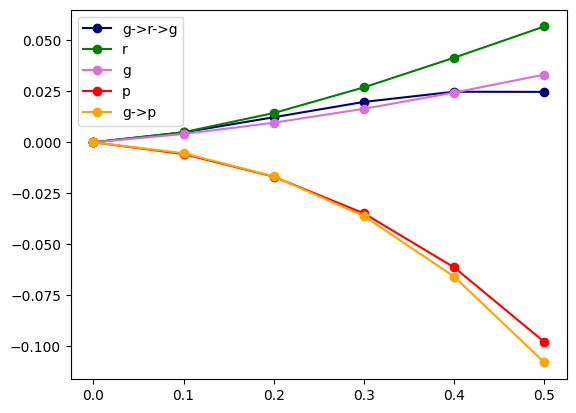

In [43]:
plt.plot(ws, results_gp_r_gp, '-o', label='g->r->g', color='navy')
plt.plot(ws, results_r, '-o', label='r', color='green')
plt.plot(ws, results_gp * 20, '-o', label='g', color='orchid')
plt.plot(ws, results_p, '-o', label='p', color='red')
plt.plot(ws, results_gp_p, '-o', label='g->p', color='orange')

plt.legend()
plt.show()

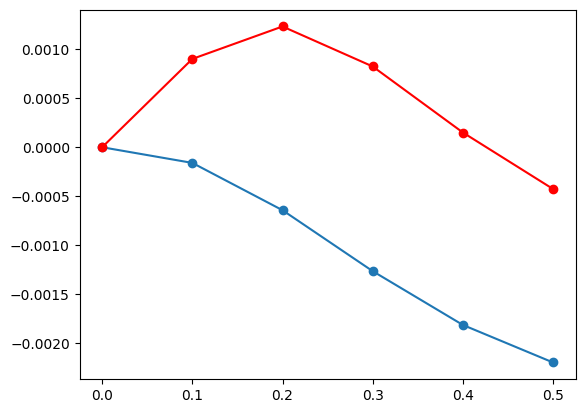

In [40]:
dw = np.zeros_like(ws)
trace = R_NULL**2

N = 50

traces = np.zeros((N, ws.size))

for i in range(N):
    T_EXT = 0.1
    U_EXT = 10
    dw_gp, trace = delta_w_single(T_EXT, R_NULL, U_EXT, trace, tau_slow, ALPHA, ws+dw)
    dw_gp_2, trace = delta_w_single(T_EXT, R_NULL, 0, trace, tau_slow, ALPHA, ws+dw)
    # traces[i] = trace
    dw += dw_gp + dw_gp_2
    
T_EXT = 0.1
U_EXT = 20
dw_gp_r, trace = delta_w_single(T_EXT, R_NULL, U_EXT, trace, tau_slow, ALPHA, ws+dw)
    
plt.plot(ws, dw_gp, '-o')
plt.plot(ws, dw_gp_r, '-o', color='red')

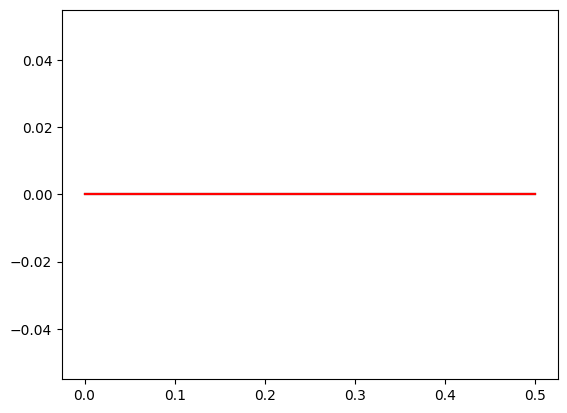

In [41]:
plt.plot(ws, traces[0:2].T, color='black')
plt.plot(ws, traces[-2:].T, color='red')